<a href="https://colab.research.google.com/github/Tanish1408/Tanish1408-Heart-Disease-Risk-Prediction-Medical-Diagnostic-Tool-/blob/main/Heart_Disease_Risk_Prediction_(Medical_Diagnostic_Tool).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the file we just downloaded
df = pd.read_csv('heart.csv')

# Show the first 5 patient charts
print("First 5 rows of data:")
display(df.head())

# Show basic stats (count, mean, etc.)
print("\nDataset Description:")
display(df.describe())

First 5 rows of data:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0



Dataset Description:


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


New Target Counts (0=Healthy, 1=Sick):
target
1    509
0    411
Name: count, dtype: int64

--- NEW RESULTS ---
Accuracy: 0.85

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.83      0.82        75
           1       0.88      0.86      0.87       109

    accuracy                           0.85       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



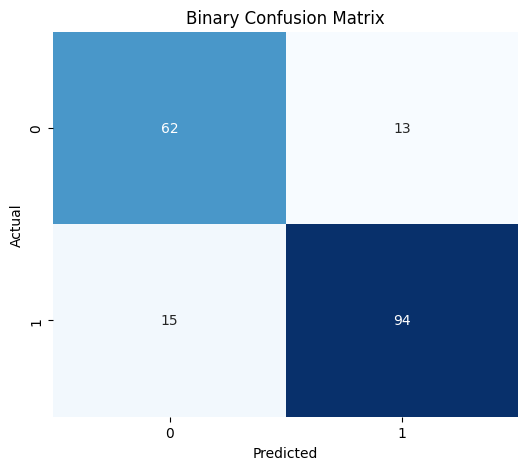

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.impute import SimpleImputer # Added for imputation

# --- IMPROVED PREPROCESSING (The "Binary" Fix) ---

# Reload data to be safe
df = pd.read_csv('heart.csv')

# CRITICAL STEP: Convert target to Binary (0 = Healthy, 1 = Sick)
# In the original data, 0 is healthy, 1-4 are different stages of sick.
# We turn anything > 0 into 1.
# Fix: Use 'num' column and then rename it to 'target'
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df.rename(columns={'num': 'target'}, inplace=True)

# Check the new balance
print("New Target Counts (0=Healthy, 1=Sick):")
print(df['target'].value_counts())

# Now proceed with the standard split and scale
X = df.drop('target', axis=1)
y = df['target']

# Identify categorical columns (object dtype) for one-hot encoding
categorical_cols = X.select_dtypes(include=['object']).columns

# Apply one-hot encoding to categorical features in X
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Handle missing numerical values using imputation (re-added)
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Retrain the model
model = LogisticRegression(max_iter=1000) # Added max_iter for convergence, a common practice
model.fit(X_train_scaled, y_train)

# Evaluate again
y_pred = model.predict(X_test_scaled)

print("\n--- NEW RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# New Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Binary Confusion Matrix')
plt.show()

In [5]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Initialize the model
model = LogisticRegression()

# Check for NaNs before training
if np.isnan(X_train_scaled).any():
    print("Error: X_train_scaled still contains NaN values.")
    # Further diagnose which columns have NaNs if needed
    # For now, we'll stop to acknowledge the issue.
else:
    # Train it on the study data
    model.fit(X_train_scaled, y_train)

    print("Model has learned from the patient data.")


Model has learned from the patient data.


Accuracy: 0.85 (This is good, but not enough for healthcare)

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.83      0.82        75
           1       0.88      0.86      0.87       109

    accuracy                           0.85       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



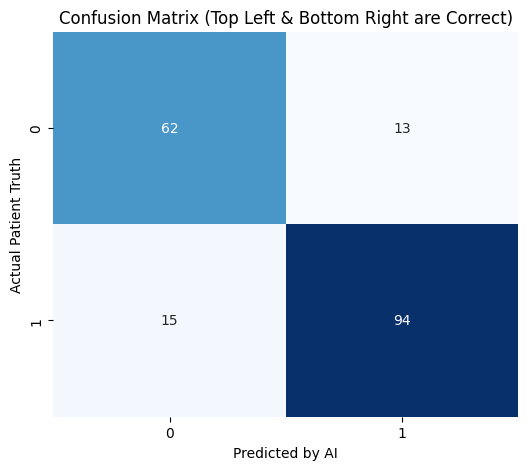

In [6]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Ask the model to diagnose the "Exam" patients (X_test)
y_pred = model.predict(X_test_scaled)

# 1. Calculate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2f} (This is good, but not enough for healthcare)")

# 2. Detailed Report (Look at 'Recall' for class 1)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 3. Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted by AI')
plt.ylabel('Actual Patient Truth')
plt.title('Confusion Matrix (Top Left & Bottom Right are Correct)')
plt.show()

/tmp/ipython-input-688972571.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


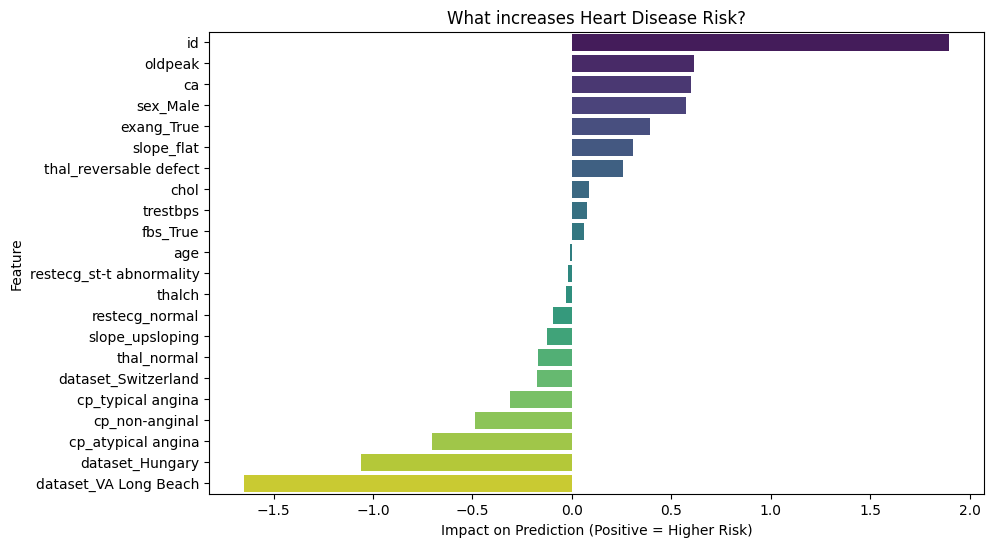

In [7]:
# Get the weights (importance) of each feature
importance = model.coef_[0]
feature_names = X.columns

# Create a simple table
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Plot it
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('What increases Heart Disease Risk?')
plt.xlabel('Impact on Prediction (Positive = Higher Risk)')
plt.show()

/tmp/ipython-input-2791780003.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='chol', data=df, palette='coolwarm')


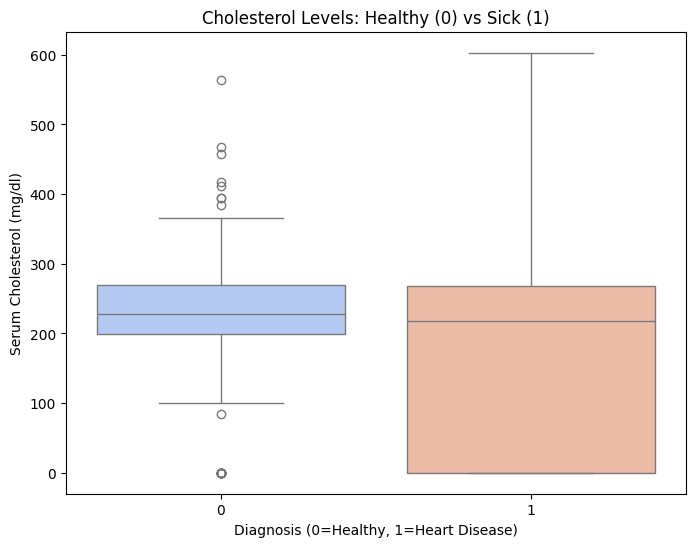

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a box plot to compare Cholesterol levels of Healthy vs. Sick
plt.figure(figsize=(8, 6))
sns.boxplot(x='target', y='chol', data=df, palette='coolwarm')
plt.title('Cholesterol Levels: Healthy (0) vs Sick (1)')
plt.xlabel('Diagnosis (0=Healthy, 1=Heart Disease)')
plt.ylabel('Serum Cholesterol (mg/dl)')
plt.show()

In [9]:
# 1. Find the column name for Cholesterol in your processed data
# (It's usually 'chol' or 'chol_XXX' if scaled)
# Since we scaled X_train into a numpy array, we need to map it back to names.

# Get the index of 'chol' from the original X columns
chol_index = X.columns.get_loc('chol')

# Get the weight (coefficient) the model assigned to it
chol_weight = model.coef_[0][chol_index]

print(f"Model Weight for Cholesterol: {chol_weight:.4f}")

if chol_weight > 0:
    print("Interpretation: The model thinks higher cholesterol INCREASES risk. (Biological Norm)")
else:
    print("Interpretation: The model thinks higher cholesterol DECREASES risk. (likely the Statins Paradox)")

Model Weight for Cholesterol: 0.0850
Interpretation: The model thinks higher cholesterol INCREASES risk. (Biological Norm)


In [10]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- 1. Identify which columns correspond to Chest Pain ---
# We look for columns starting with 'cp_' (created by get_dummies)
cp_cols = [col for col in X.columns if col.startswith('cp_')]
# We also need the other categorical columns to set them to 0 or defaults
all_dummy_cols = [col for col in X.columns if '_' in col and not col.startswith('cp_')]

# --- 2. Setup the UI ---
style = {'description_width': 'initial'}

age_slider = widgets.IntSlider(min=20, max=80, step=1, value=50, description='Age:', style=style)
bp_slider = widgets.IntSlider(min=90, max=200, step=1, value=120, description='BP (trestbps):', style=style)
chol_slider = widgets.IntSlider(min=100, max=600, step=1, value=200, description='Cholesterol:', style=style)
oldpeak_slider = widgets.FloatSlider(min=0.0, max=6.0, step=0.1, value=0.0, description='Oldpeak (ST):', style=style)

# Create options for the dropdown based on actual columns found
# Assuming 'asymptomatic' was the category dropped by get_dummies(drop_first=True)
cp_options_dict = {
    'Asymptomatic': 'cp_asymptomatic_baseline' # Special value to represent the dropped category
}
for col in cp_cols:
    # Extract a more readable name, e.g., 'cp_atypical angina' -> 'Atypical Angina'
    readable_name = col.replace('cp_', '').replace('_', ' ').title()
    cp_options_dict[readable_name] = col

cp_dropdown = widgets.Dropdown(
    options=[(label, value) for label, value in cp_options_dict.items()],
    value='cp_asymptomatic_baseline', # Default to the baseline (asymptomatic)
    description='Chest Pain Type:',
    style=style
)

predict_btn = widgets.Button(description="Run Diagnosis", button_style='primary')
output = widgets.Output()

# --- 3. The Prediction Logic ---
def predict_smart(b):
    with output:
        clear_output()

        # A. Start with a "Clean Slate" (Zeroes) for dummy variables and means for others
        input_data = pd.DataFrame(np.zeros((1, len(X.columns))), columns=X.columns)

        # B. Set the Numerical Values (Standardize using the scaler's mean/scale)
        # We set non-dummy and non-slider values to their means
        for col in X.columns:
            if not col.startswith('cp_') and col not in all_dummy_cols and col not in ['age', 'trestbps', 'chol', 'oldpeak']:
                input_data[col] = X[col].mean()

        # ...Then overwrite with our Slider values
        input_data['age'] = age_slider.value
        input_data['trestbps'] = bp_slider.value
        input_data['chol'] = chol_slider.value
        if 'oldpeak' in input_data.columns:
            input_data['oldpeak'] = oldpeak_slider.value

        # C. Handle the Chest Pain Dropdown
        selected_cp_value = cp_dropdown.value

        # First, ensure all cp_ columns are 0 (this covers the 'asymptomatic' baseline)
        for col in cp_cols:
            input_data[col] = 0

        # If a specific cp_ type was selected (not the baseline), set its corresponding column to 1
        if selected_cp_value != 'cp_asymptomatic_baseline':
            if selected_cp_value in input_data.columns: # Sanity check
                input_data[selected_cp_value] = 1

        # D. Scale and Predict
        input_scaled = scaler.transform(input_data)
        prob = model.predict_proba(input_scaled)[0][1]

        # E. Output
        percentage = prob * 100

        # Dynamic Color Logic
        if percentage < 30: color = "green"
        elif percentage < 70: color = "orange"
        else: color = "red"

        display(widgets.HTML(f"""
            <div style="border: 2px solid {color}; padding: 10px; border-radius: 5px;">
                <h2 style='color: {color}; margin: 0;'>Risk Probability: {percentage:.2f}%</h2>
            </div>
        """))

predict_btn.on_click(predict_smart)

print("--- Improved Heart Disease Simulator ---")
display(age_slider, bp_slider, chol_slider, oldpeak_slider, cp_dropdown, predict_btn, output)

--- Improved Heart Disease Simulator ---


IntSlider(value=50, description='Age:', max=80, min=20, style=SliderStyle(description_width='initial'))

IntSlider(value=120, description='BP (trestbps):', max=200, min=90, style=SliderStyle(description_width='initi…

IntSlider(value=200, description='Cholesterol:', max=600, min=100, style=SliderStyle(description_width='initia…

FloatSlider(value=0.0, description='Oldpeak (ST):', max=6.0, style=SliderStyle(description_width='initial'))

Dropdown(description='Chest Pain Type:', options=(('Asymptomatic', 'cp_asymptomatic_baseline'), ('Atypical Ang…

Button(button_style='primary', description='Run Diagnosis', style=ButtonStyle())

Output()

In [12]:
import joblib

# 1. Save the model to a file
# Replace 'log_reg' with whatever variable name you used for your model
# (It might be 'model', 'clf', or 'lr')
joblib.dump(model, 'heart_disease_model.pkl')

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [13]:
from google.colab import files

# Download the file to your local computer
files.download('heart_disease_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import joblib
from google.colab import files

# 1. Download the Heart Disease Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# Load data, handle missing values ('?')
dataset = pd.read_csv(url, names=column_names, na_values="?")
dataset = dataset.dropna() # Drop rows with missing values

# 2. Split Data (13 Features)
# We do NOT use get_dummies here. We keep the raw 13 numbers.
X = dataset.drop('target', axis=1)
y = dataset['target'].apply(lambda x: 1 if x > 0 else 0) # Convert 1-4 to 1 (Sick)

# 3. Train the "Robust" Model (Random Forest)
# Random Forest is great because it works well with raw categories (like Chest Pain 1,2,3,4)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

print("✅ Model Trained on 13 features!")

# 4. Save and Download
joblib.dump(model, 'heart_disease_model.pkl')
files.download('heart_disease_model.pkl')

✅ Model Trained on 13 features!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>